In [21]:
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_generation.fair_world import simulate_fair_world


from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import (
    MLP,
    train_epoch,
    evaluate,
    train,
    plot,
    train_mlp_model
)

from src.metrics.fairness import (
    fairness_by_group,
    equal_opportunity_diff,
    equalized_odds_diff
)

import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
device


'mps'

In [23]:
df = simulate_fair_world(n_samples=10000, seed=SEED)
df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,0,66.807657,86.260274,5.264139,0
1,2,1,49.977538,94.787618,4.977199,0
2,1,1,41.819978,88.619829,5.321474,0
3,0,1,51.230187,103.810522,5.338681,0
4,0,0,44.494660,165.847420,7.429512,1


In [25]:
df.to_csv("df_fair.csv", index=False)

print("Datasets saved!")

Datasets saved!


In [16]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 8000
Test size: 2000
Prevalence: 0.199375


In [17]:
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)


In [18]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUC:", lr_results["AUROC"])


LR Accuracy: 0.998
LR AUC: 0.99987946157301


Epoch 1/20: train_loss=0.1781, train_acc=94.51, val_loss=0.0168, val_acc=99.65
Epoch 2/20: train_loss=0.0076, train_acc=99.90, val_loss=0.0100, val_acc=99.80
Epoch 3/20: train_loss=0.0039, train_acc=99.91, val_loss=0.0093, val_acc=99.80
Epoch 4/20: train_loss=0.0029, train_acc=99.91, val_loss=0.0081, val_acc=99.80
Epoch 5/20: train_loss=0.0025, train_acc=99.94, val_loss=0.0074, val_acc=99.85
Epoch 6/20: train_loss=0.0023, train_acc=99.92, val_loss=0.0086, val_acc=99.80
Epoch 7/20: train_loss=0.0021, train_acc=99.91, val_loss=0.0069, val_acc=99.85
Epoch 8/20: train_loss=0.0020, train_acc=99.90, val_loss=0.0091, val_acc=99.80
Epoch 9/20: train_loss=0.0019, train_acc=99.91, val_loss=0.0081, val_acc=99.80
Epoch 10/20: train_loss=0.0018, train_acc=99.95, val_loss=0.0083, val_acc=99.80
Epoch 11/20: train_loss=0.0018, train_acc=99.91, val_loss=0.0085, val_acc=99.80
Epoch 12/20: train_loss=0.0017, train_acc=99.94, val_loss=0.0082, val_acc=99.85
Epoch 13/20: train_loss=0.0016, train_acc=99.95, 

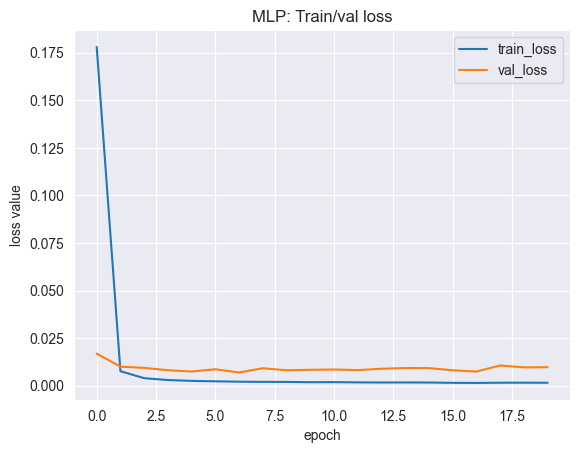

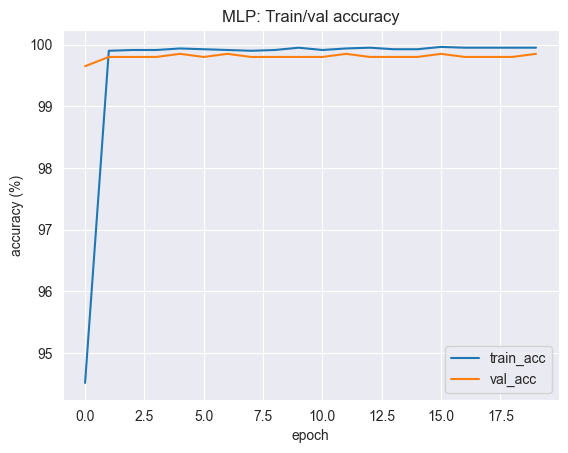

In [19]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)

print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUC:", mlp_results["AUROC"])


In [28]:
mlp_train_fair = mlp_results["train_losses"]
mlp_val_fair = mlp_results["val_losses"]

with open("mlp_fair_curves.json", "w") as f:
    json.dump({
        "train_losses": mlp_train_fair,
        "val_losses": mlp_val_fair
    }, f)


In [9]:
df_test = df.loc[X_test.index].copy()

print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], df_test["race"])
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], df_test["gender"])
print(lr_fair_gender)

LR_EO_race = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)



print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], df_test["race"])
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], df_test["gender"])
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
   FPR       FNR       TPR  TNR
0  0.0  0.004902  0.995098  1.0
1  0.0  0.010526  0.989474  1.0
2  0.0  0.000000  1.000000  1.0

=== LR Fairness by Gender ===
   FPR       FNR       TPR  TNR
0  0.0  0.005376  0.994624  1.0
1  0.0  0.005587  0.994413  1.0

=== MLP Fairness by Race ===
        FPR  FNR  TPR       TNR
0  0.001009  0.0  1.0  0.998991
1  0.000000  0.0  1.0  1.000000
2  0.000000  0.0  1.0  1.000000

=== MLP Fairness by Gender ===
        FPR  FNR  TPR       TNR
0  0.001241  0.0  1.0  0.998759
1  0.000000  0.0  1.0  1.000000


In [29]:
mlp_fair_race.to_json("fair_tpr_by_race.json", orient="index")
print("Saved Fair TPR-by-race → fair_tpr_by_race.json")


Saved Fair TPR-by-race → fair_tpr_by_race.json


In [10]:
results_fair = {
    "world_name": "Fair",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_fair


{'world_name': 'Fair',
 'LR_accuracy': 0.999,
 'LR_AUROC': 0.9999983243265888,
 'LR_EO_race': 0.010526315789473717,
 'LR_EO_gender': 0.00021024809274949874,
 'MLP_accuracy': np.float64(0.9995),
 'MLP_AUROC': 1.0,
 'MLP_EO_race': 0.0,
 'MLP_EO_gender': 0.0}

In [27]:
results_fair = {
    "world_name": "Fair",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

json.dump(results_fair, open("results_fair.json", "w"), indent=4)
print("Saved fair world → results_fair.json")

Saved fair world → results_fair.json
